#### Modules

In [3]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
from tabulate import tabulate

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import folium
from shapely.geometry import Point # For geographic data handling (questionable coordinates)



# ---- Temporal and Spatial Autocorrelation ----
from skgstat import Variogram 
from skgstat import SpaceTimeVariogram
from statsmodels.graphics.tsaplots import plot_acf #for temporal autocorrelation


#--- Custom Functions as defined by the user ---
import sys
sys.path.append(os.path.abspath("tools"))
import functions




In [4]:
# for visualising tables: 
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

Define data summary function 

In [5]:
df_raw = pd.read_csv("../../../data/finaldatasets/testdata/XGBoost.csv")  # for variogram, etc.


In [21]:
functions.summarize_dataframe(df_raw)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| start_date                                            | int64   |   69430 |          100   |          7 |
| AEZ                                                   | float64 |   69430 |          100   |         31 |
| Data.ID                                               | object  |   69430 |          100   |         51 |
| temp1                                                 | float64 |   69430 |          100   |        268 |
| temp2                                                 | float64 |   69430 |          100   |        270 |
| temp3                                                 | float64 |   69430 |          100   |        275 |
| temp4                     

In [22]:
functions.summarize_dataframe(df_raw)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| start_date                                            | int64   |   69430 |          100   |          7 |
| AEZ                                                   | float64 |   69430 |          100   |         31 |
| Data.ID                                               | object  |   69430 |          100   |         51 |
| temp1                                                 | float64 |   69430 |          100   |        268 |
| temp2                                                 | float64 |   69430 |          100   |        270 |
| temp3                                                 | float64 |   69430 |          100   |        275 |
| temp4                     

In [23]:
# See how many unique locations vs total records
unique_locations = df_raw.groupby(["Conversion.for.latitude", "Conversion.for.longitude"]).size()
print(f"Total records: {len(df_raw)}")
print(f"Unique locations: {len(unique_locations)}")
print(f"Average records per location: {len(df_raw) / len(unique_locations):.2f}")

Total records: 69430
Unique locations: 248
Average records per location: 279.96


In [25]:

pd.set_option('display.max_rows',None )  # Limit display for clarity
# Group by location and summarize year range
temporal_range_per_location = df_raw.groupby(
    ["Conversion.for.latitude", "Conversion.for.longitude"]
)["year"].agg(['min', 'max', 'nunique']).reset_index()

# Rename columns for clarity
temporal_range_per_location.columns = [
    "lat", "lon", "year_start", "year_end", "n_years"
]

# Sort to see longest or shortest ranges
temporal_range_per_location.sort_values("n_years", ascending=False).head()


,lat,lon,year_start,year_end,n_years
227,51.809472,-0.373000,2005,2020,15
159,38.524167,-121.743944,2005,2019,14
117,35.448861,-119.163944,2005,2019,14
32,27.507472,-109.896694,2005,2019,14
153,38.062694,-121.572361,2005,2019,13


Create a spatial autocorrelation variogram, code inspiriation from : https://phys-techsciences.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/dans-zwj-zauq

Analyzing 248 unique locations...

SPATIAL AUTOCORRELATION RESULTS
Threshold (Range): 16.2 km
Sill: 6.87
Nugget: 0.00

Current (100km) vs Calculated (16.2km)
Difference: 83.8 km
Recommendation: Consider 16km
💡 Consider adjustment


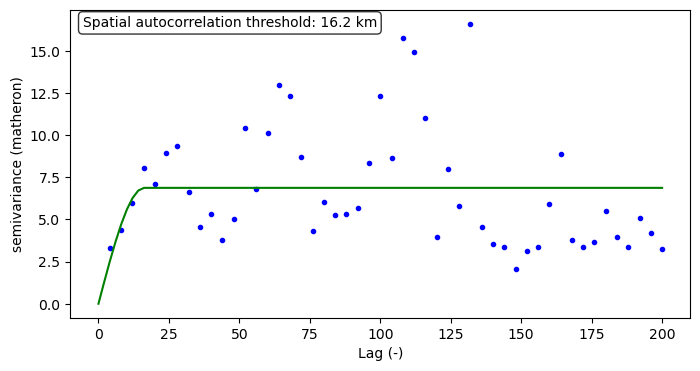

In [26]:
from skgstat import Variogram
import matplotlib.pyplot as plt

# Step 1: Aggregate yield by unique lat-lon
location_avg = df_raw.groupby(
    ["Conversion.for.latitude", "Conversion.for.longitude"]
)["Grain.yield..tons.ha.1."].mean().reset_index()

# Extract coordinates and values
coordinates = location_avg[["Conversion.for.latitude", "Conversion.for.longitude"]].values
yields = location_avg["Grain.yield..tons.ha.1."].values


def calculate_autocorrelation_threshold(
    coords, values, model='exponential', metric='greatcircle', 
    n_lags=50, max_lag=200
):
    """Fit a semivariogram and return the range (autocorrelation threshold)"""
    variogram = Variogram(
        coordinates=coords,
        values=values,
        model=model,
        metric=metric,
        n_lags=n_lags,
        maxlag=max_lag
    )
    threshold = variogram.parameters[0]
    
    fig = variogram.plot(grid=False, hist=False)
    fig.text(
        0.02, 0.98, f"Spatial autocorrelation threshold: {threshold:.1f} km",
        transform=fig.gca().transAxes, verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )
    return threshold, fig, variogram


def extract_variogram_params(variogram):
    """Extract sill and nugget from a Variogram object"""
    sill = getattr(variogram, 'sill', None)
    nugget = getattr(variogram, 'nugget', None)
    
    if sill is None and len(variogram.parameters) > 1:
        sill = variogram.parameters[1]
    if nugget is None and len(variogram.parameters) > 2:
        nugget = variogram.parameters[2]
        
    return sill, nugget


def assess_clustering_distance(current_km, threshold_km, tolerance=25):
    """Compare current clustering distance to estimated threshold"""
    diff = abs(current_km - threshold_km)
    recommendation = (
        f"Keep {current_km}km" if diff < tolerance else f"Consider {threshold_km:.0f}km"
    )
    return {
        'difference': diff,
        'within_tolerance': diff < tolerance,
        'recommendation': recommendation
    }


# === FUNCTION CALL (easy to tweak) ===
print(f"Analyzing {len(coordinates)} unique locations...")
sp_threshold, fig, variogram = calculate_autocorrelation_threshold(
    coords=coordinates,
    values=yields,
    model='spherical',           # try 'exponential' or 'gaussian'
    metric='greatcircle',        # haversine distance (in km)
    n_lags=50,
    max_lag=200
)

sill, nugget = extract_variogram_params(variogram)

# === Print summary ===
print("\n" + "="*50)
print("SPATIAL AUTOCORRELATION RESULTS")
print("="*50)
print(f"Threshold (Range): {sp_threshold:.1f} km")
if sill is not None: print(f"Sill: {sill:.2f}")
if nugget is not None: print(f"Nugget: {nugget:.2f}")

# === Evaluate clustering strategy ===
evaluation = assess_clustering_distance(100, sp_threshold)
print(f"\nCurrent (100km) vs Calculated ({sp_threshold:.1f}km)")
print(f"Difference: {evaluation['difference']:.1f} km")
print(f"Recommendation: {evaluation['recommendation']}")
print("✅ Well-justified!" if evaluation['within_tolerance'] else "💡 Consider adjustment")


In [7]:
"""
Simple Variogram Analysis - Streamlined & Interpretable
Clean, minimal code for spatial autocorrelation analysis
"""

from skgstat import Variogram
import pandas as pd
import numpy as np

def analyze_spatial_autocorrelation(df, year_col, lat_col, lon_col, yield_col):
    """
    Analyze spatial autocorrelation for crop yields by year
    
    Inputs:
    - df: your DataFrame
    - year_col, lat_col, lon_col, yield_col: column names (strings)
    
    Returns:
    - results_table: DataFrame with results
    """
    
    results = []
    years = sorted(df[year_col].dropna().unique())
    
    print(f"Analyzing {len(years)} years: {years}")
    print("-" * 50)
    
    for year in years:
        # Get data for this year
        year_data = df[df[year_col] == year]
        
        # Average yields by location (in case of duplicates)
        locations = year_data.groupby([lat_col, lon_col])[yield_col].mean().reset_index()
        
        # Need at least 10 locations for reliable analysis
        if len(locations) < 10:
            print(f"{year}: Skipped - only {len(locations)} locations")
            continue
        
        # Extract coordinates and yields
        coords = locations[[lat_col, lon_col]].values
        yields = locations[yield_col].values
        
        try:
            # Calculate variogram (spatial autocorrelation model)
            variogram = Variogram(
                coordinates=coords,
                values=yields,
                model='spherical',      # model type
                metric='greatcircle',   # distance calculation
                n_lags=40,             # number of distance bins
                maxlag=200             # max distance (km)
            )
            
            # Get the range (distance where autocorrelation stops)
            spatial_range = variogram.parameters[0]
            
            # Calculate Moran's I using PySAL (if available)
            morans_i, p_value = calculate_morans_i(coords, yields, spatial_range)
            
            # Determine significance
            if p_value < 0.05:
                significance = "Significant"
            else:
                significance = "Not significant"
            
            # Store results
            results.append({
                'Year': year,
                'Locations': len(locations),
                'Range_km': round(spatial_range, 1),
                'Morans_I': round(morans_i, 3),
                'p_value': round(p_value, 3),
                'Significance': significance
            })
            
            print(f"{year}: Range = {spatial_range:.1f} km, Moran's I = {morans_i:.3f} ({significance})")
            
        except Exception as e:
            print(f"{year}: Failed - {e}")
    
    # Convert to DataFrame
    results_table = pd.DataFrame(results)
    
    # Print summary
    if not results_table.empty:
        print("\n" + "="*60)
        print("SUMMARY")
        print("="*60)
        
        significant_years = len(results_table[results_table['Significance'] == 'Significant'])
        total_years = len(results_table)
        avg_range = results_table['Range_km'].mean()
        
        print(f"Years analyzed: {total_years}")
        print(f"Years with significant spatial autocorrelation: {significant_years}/{total_years}")
        print(f"Average spatial range: {avg_range:.1f} km")
        print(f"Recommended clustering distance: ~{avg_range:.0f} km")
        
        print(f"\nFull Results:")
        print(results_table.to_string(index=False))
    
    return results_table

def calculate_morans_i(coords, values, threshold_km):
    """
    Calculate Moran's I using PySAL (preferred) or custom method
    """
    try:
        # Try PySAL first (most reliable)
        from libpysal.weights import DistanceBand
        from esda.moran import Moran
        
        # Convert km to degrees (approximate: 1 degree ≈ 111 km)
        threshold_degrees = threshold_km / 111.0
        
        # Create spatial weights
        weights = DistanceBand.from_array(coords, threshold=threshold_degrees)
        
        # Calculate Moran's I
        moran = Moran(values, weights)
        
        return moran.I, moran.p_norm
        
    except ImportError:
        print("Note: Install PySAL for better Moran's I calculation: pip install libpysal esda")
        return calculate_morans_i_simple(coords, values, threshold_km)

def calculate_morans_i_simple(coords, values, threshold_km):
    """
    Simple Moran's I calculation (fallback if PySAL not available)
    """
    from sklearn.metrics.pairwise import haversine_distances
    from scipy import stats
    
    # Calculate distances between all location pairs
    coords_rad = np.radians(coords)  # Convert to radians
    distances = haversine_distances(coords_rad) * 6371  # Earth radius = 6371 km
    
    # Create neighbor matrix (1 if within threshold, 0 if not)
    neighbors = (distances <= threshold_km) & (distances > 0)  # Exclude self
    
    # Standardize the neighbor weights
    row_sums = neighbors.sum(axis=1)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    weights = neighbors / row_sums[:, np.newaxis]
    
    # Calculate Moran's I
    n = len(values)
    mean_value = np.mean(values)
    centered_values = values - mean_value
    
    # Moran's I formula
    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += weights[i, j] * centered_values[i] * centered_values[j]
    
    denominator = np.sum(centered_values**2)
    total_weights = np.sum(weights)
    
    if denominator == 0 or total_weights == 0:
        return 0, 1.0
    
    morans_i = (n / total_weights) * (numerator / denominator)
    
    # Simple significance test
    expected_i = -1 / (n - 1)
    
    # Approximate z-score (simplified)
    variance_approx = 1 / (n - 1)
    z_score = (morans_i - expected_i) / np.sqrt(variance_approx)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # Two-tailed test
    
    return morans_i, p_value

# ===== USAGE =====
def run_analysis(df, year_col='year', lat_col='Conversion.for.latitude', 
                lon_col='Conversion.for.longitude', yield_col='Grain.yield..tons.ha.1.'):
    """
    Main function - just call this with your DataFrame!
    
    Example:
    results = run_analysis(df_raw)
    """
    print("🌾 SPATIAL AUTOCORRELATION ANALYSIS")
    print("="*50)
    
    results = analyze_spatial_autocorrelation(df, year_col, lat_col, lon_col, yield_col)
    
    return results

# Example usage:
print("📋 SIMPLE VARIOGRAM ANALYSIS - READY!")
print("="*40)
print("Usage:")
print("results = run_analysis(df_raw)")
print("")
print("With custom column names:")
print("results = run_analysis(df_raw, ")
print("                      year_col='your_year_column',")
print("                      lat_col='your_lat_column',") 
print("                      lon_col='your_lon_column',")
print("                      yield_col='your_yield_column')")
print("")
print("Save results:")
print("results.to_csv('spatial_analysis_results.csv', index=False)")

run_analysis(df_raw)

📋 SIMPLE VARIOGRAM ANALYSIS - READY!
Usage:
results = run_analysis(df_raw)

With custom column names:
results = run_analysis(df_raw, 
                      year_col='your_year_column',
                      lat_col='your_lat_column',
                      lon_col='your_lon_column',
                      yield_col='your_yield_column')

Save results:
results.to_csv('spatial_analysis_results.csv', index=False)
🌾 SPATIAL AUTOCORRELATION ANALYSIS
Analyzing 15 years: [2005, 2006, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
--------------------------------------------------
 There are 18 disconnected components.
 There are 17 islands with ids: 0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18.
 There are 18 disconnected components.
 There are 17 islands with ids: 0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18.
('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 4, ' is an island 

,Year,Locations,Range_km,Morans_I,p_value,Significance
0,2005,19,25.5,-0.250,0.838,Not significant
1,2006,16,99.9,1.068,0.089,Not significant
2,2008,27,11.7,0.009,0.961,Not significant
3,2009,24,115.1,-0.111,0.866,Not significant
4,2010,33,32.7,0.257,0.608,Not significant
5,2011,36,28.3,0.188,0.701,Not significant
6,2012,33,27.1,0.828,0.077,Not significant
7,2013,45,12.0,0.169,0.734,Not significant
8,2014,62,9.9,0.134,0.697,Not significant
9,2015,57,12.1,-0.005,0.989,Not significant


In [ ]:
# Count number of unique IDs per lat/lon point
ids_count = df_raw.groupby(["Conversion.for.latitude", "Conversion.for.longitude"])["id"].nunique().reset_index()
years_count = df_raw.groupby(["Conversion.for.latitude", "Conversion.for.longitude"])["year"].nunique().reset_index()

# Merge counts into one DataFrame
ids_per_location = ids_count.merge(
	years_count,
	on=["Conversion.for.latitude", "Conversion.for.longitude"],
	suffixes=('_ids', '_years')
)
ids_per_location.columns = ['latitude', 'longitude', 'num_ids', 'num_years']

# Show the table
print(ids_per_location)

ids_per_location.to_csv("ids_per_location.csv", index=False)

ids_per_location.to_csv("chatgpt.csv")



      latitude   longitude  num_ids  num_years
0   -37.824167  142.070833       10          2
1   -37.785000  142.102500        5          1
2   -34.480000  145.950000        4          1
3   -31.484000  150.177000        6          1
4   -29.720278  -53.705278        6          1
5   -27.512361  151.781806        3          1
6   -27.274042  -50.504003        5          1
7   -26.971333  152.390361        4          1
8   -26.174500  -52.686917       33          1
9   -23.200000  -52.183333        6          2
10  -20.366667  -51.366667       14          3
11   -2.223333   37.737111     7053          4
12    5.434389   37.842778     1641          4
13    7.036472   40.227222      140          2
14    7.072250   40.213861      864          1
15    7.104944   39.209056       15          1
16    7.520694   39.260778       15          1
17    8.019444   39.153056        6          1
18    8.021528   39.156389       89          2
19    8.761389   39.008389       75          1
20    8.77433

#### Temporally stratified Spaciovariogram and Morans I Correllogram

In [2]:
"""
Simple Variogram Analysis - Streamlined & Interpretable
Clean, minimal code for spatial autocorrelation analysis
"""

from skgstat import Variogram
import pandas as pd
import numpy as np

def analyze_spatial_autocorrelation(df, year_col, lat_col, lon_col, yield_col):
    """
    Analyze spatial autocorrelation for crop yields by year
    
    Inputs:
    - df: your DataFrame
    - year_col, lat_col, lon_col, yield_col: column names (strings)
    
    Returns:
    - results_table: DataFrame with results
    """
    
    results = []
    years = sorted(df[year_col].dropna().unique())
    
    print(f"Analyzing {len(years)} years: {years}")
    print("-" * 50)
    
    for year in years:
        # Get data for this year
        year_data = df[df[year_col] == year]
        
        # Average yields by location (in case of duplicates)
        locations = year_data.groupby([lat_col, lon_col])[yield_col].mean().reset_index()
        
        # Need at least 10 locations for reliable analysis
        if len(locations) < 10:
            print(f"{year}: Skipped - only {len(locations)} locations")
            continue
        
        # Extract coordinates and yields
        coords = locations[[lat_col, lon_col]].values
        yields = locations[yield_col].values
        
        try:
            # Calculate variogram (spatial autocorrelation model)
            variogram = Variogram(
                coordinates=coords,
                values=yields,
                model='spherical',      # model type
                metric='greatcircle',   # distance calculation
                n_lags=40,             # number of distance bins
                maxlag=200             # max distance (km)
            )
            
            # Get the range (distance where autocorrelation stops)
            spatial_range = variogram.parameters[0]
            
            # Calculate Moran's I using PySAL (if available)
            morans_i, p_value = calculate_morans_i(coords, yields, spatial_range)
            
            # Determine significance
            if p_value < 0.05:
                significance = "Significant"
            else:
                significance = "Not significant"
            
            # Store results
            results.append({
                'Year': year,
                'Locations': len(locations),
                'Range_km': round(spatial_range, 1),
                'Morans_I': round(morans_i, 3),
                'p_value': round(p_value, 3),
                'Significance': significance
            })
            
            print(f"{year}: Range = {spatial_range:.1f} km, Moran's I = {morans_i:.3f} ({significance})")
            
        except Exception as e:
            print(f"{year}: Failed - {e}")
    
    # Convert to DataFrame
    results_table = pd.DataFrame(results)
    
    # Print summary
    if not results_table.empty:
        print("\n" + "="*60)
        print("SUMMARY")
        print("="*60)
        
        significant_years = len(results_table[results_table['Significance'] == 'Significant'])
        total_years = len(results_table)
        avg_range = results_table['Range_km'].mean()
        
        print(f"Years analyzed: {total_years}")
        print(f"Years with significant spatial autocorrelation: {significant_years}/{total_years}")
        print(f"Average spatial range: {avg_range:.1f} km")
        print(f"Recommended clustering distance: ~{avg_range:.0f} km")
        
        print(f"\nFull Results:")
        print(results_table.to_string(index=False))
    
    return results_table

def calculate_morans_i(coords, values, threshold_km):
    """
    Calculate Moran's I using PySAL (preferred) or custom method
    """
    try:
        # Try PySAL first (most reliable)
        from libpysal.weights import DistanceBand
        from esda.moran import Moran
        
        # Convert km to degrees (approximate: 1 degree ≈ 111 km)
        threshold_degrees = threshold_km / 111.0
        
        # Create spatial weights
        weights = DistanceBand.from_array(coords, threshold=threshold_degrees)
        
        # Calculate Moran's I
        moran = Moran(values, weights)
        
        return moran.I, moran.p_norm
        
    except ImportError:
        print("Note: Install PySAL for better Moran's I calculation: pip install libpysal esda")
        return calculate_morans_i_simple(coords, values, threshold_km)

def calculate_morans_i_simple(coords, values, threshold_km):
    """
    Simple Moran's I calculation (fallback if PySAL not available)
    """
    from sklearn.metrics.pairwise import haversine_distances
    from scipy import stats
    
    # Calculate distances between all location pairs
    coords_rad = np.radians(coords)  # Convert to radians
    distances = haversine_distances(coords_rad) * 6371  # Earth radius = 6371 km
    
    # Create neighbor matrix (1 if within threshold, 0 if not)
    neighbors = (distances <= threshold_km) & (distances > 0)  # Exclude self
    
    # Standardize the neighbor weights
    row_sums = neighbors.sum(axis=1)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    weights = neighbors / row_sums[:, np.newaxis]
    
    # Calculate Moran's I
    n = len(values)
    mean_value = np.mean(values)
    centered_values = values - mean_value
    
    # Moran's I formula
    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += weights[i, j] * centered_values[i] * centered_values[j]
    
    denominator = np.sum(centered_values**2)
    total_weights = np.sum(weights)
    
    if denominator == 0 or total_weights == 0:
        return 0, 1.0
    
    morans_i = (n / total_weights) * (numerator / denominator)
    
    # Simple significance test
    expected_i = -1 / (n - 1)
    
    # Approximate z-score (simplified)
    variance_approx = 1 / (n - 1)
    z_score = (morans_i - expected_i) / np.sqrt(variance_approx)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # Two-tailed test
    
    return morans_i, p_value

# ===== USAGE =====
def run_analysis(df, year_col='year', lat_col='Conversion.for.latitude', 
                lon_col='Conversion.for.longitude', yield_col='Grain.yield..tons.ha.1.'):
    """
    Main function - just call this with your DataFrame!
    
    Example:
    results = run_analysis(df_raw)
    """
    print("🌾 SPATIAL AUTOCORRELATION ANALYSIS")
    print("="*50)
    
    results = analyze_spatial_autocorrelation(df, year_col, lat_col, lon_col, yield_col)
    
    return results

# Example usage:
print("📋 SIMPLE VARIOGRAM ANALYSIS - READY!")
print("="*40)
print("Usage:")
print("results = run_analysis(df_raw)")
print("")
print("With custom column names:")
print("results = run_analysis(df_raw, ")
print("                      year_col='your_year_column',")
print("                      lat_col='your_lat_column',") 
print("                      lon_col='your_lon_column',")
print("                      yield_col='your_yield_column')")
print("")
print("Save results:")
print("results.to_csv('spatial_analysis_results.csv', index=False)")

results = run_analysis(df_raw)

📋 SIMPLE VARIOGRAM ANALYSIS - READY!
Usage:
results = run_analysis(df_raw)

With custom column names:
results = run_analysis(df_raw, 
                      year_col='your_year_column',
                      lat_col='your_lat_column',
                      lon_col='your_lon_column',
                      yield_col='your_yield_column')

Save results:
results.to_csv('spatial_analysis_results.csv', index=False)


NameError: name 'df_raw' is not defined